In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'


In [2]:
dir = os.listdir('PlantVillage')  # Check for available classes
for filenames in dir:
    print(filenames)

Pepper__bell___Bacterial_spot
Pepper__bell___healthy
Potato___Early_blight
Potato___healthy
Potato___Late_blight
Tomato_Bacterial_spot
Tomato_Early_blight
Tomato_healthy
Tomato_Late_blight
Tomato_Leaf_Mold
Tomato_Septoria_leaf_spot
Tomato_Spider_mites_Two_spotted_spider_mite
Tomato__Target_Spot
Tomato__Tomato_mosaic_virus
Tomato__Tomato_YellowLeaf__Curl_Virus
UNKNOWN


In [3]:
# !cp -rf PlantVillage/Tomato_Early_blight ./Tomato_Early_blight
# !cp -rf PlantVillage/Tomato_Late_blight ./Tomato_Late_blight
# !cp -rf PlantVillage/Tomato_healthy ./Tomato_healthy
# !cp -rf PlantVillage/Tomato_Bacterial_spot ./Tomato_Bacterial_spot
# !cp -rf PlantVillage/Tomato_Leaf_Mold ./Tomato_Leaf_Mold
# !cp -rf PlantVillage/Tomato_Septoria_leaf_spot ./Tomato_Septoria_leaf_spot
# !cp -rf PlantVillage/Tomato_Spider_mites_Two_spotted_spider_mite ./Tomato_Spider_mites_Two_spotted_spider_mite
# !cp -rf PlantVillage/Tomato__Target_Spot ./Tomato__Target_Spot
# !cp -rf PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus ./Tomato__Tomato_YellowLeaf__Curl_Virus
# !cp -rf PlantVillage/Tomato__Tomato_mosaic_virus ./Tomato__Tomato_mosaic_virus


In [4]:


# Define image dimensions and batch size
img_height = 180
img_width = 180
batch_size = 32

# Corrected class_names to match subdirectory names exactly
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    './PlantVillage',  # Parent directory containing subdirectories
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    class_names=[
        'Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy',
        'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy',
        'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight',
        'Tomato_healthy', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot',
        'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot',
        'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus',
        'UNKNOWN'
    ]
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    './PlantVillage',  # Same parent directory
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    class_names=[
        'Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy',
        'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy',
        'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight',
        'Tomato_healthy', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot',
        'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot',
        'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus',
        'UNKNOWN'
    ]
)


Found 20646 files belonging to 16 classes.
Using 16517 files for training.
Found 20646 files belonging to 16 classes.
Using 4129 files for validation.


In [5]:
num_classes = 10
img_height = 128  # example height
img_width = 128   # example width

model = tf.keras.Sequential([
    layers.InputLayer(shape=(img_height, img_width, 3)),  # input layer
    layers.Rescaling(1./255),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

# Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Add early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Training data generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation data generator without augmentation
val_datagen = ImageDataGenerator(rescale=1./255)

# Load training data from directory
train_ds = train_datagen.flow_from_directory(
    r'C:\Users\harsh\OneDrive\Documents\project alok\PlantVillage',           # Replace with actual path
    target_size=(128, 128),         # Image size for the model input
    batch_size=32,                  # Number of images per batch
    class_mode='sparse'             # Use 'sparse' for integer labels
)

# Load validation data from directory
val_ds = val_datagen.flow_from_directory(
    r'C:\Users\harsh\OneDrive\Documents\project alok\PlantVillage',             # Replace with actual path
    target_size=(128, 128),         # Image size for the model input
    batch_size=32,                  # Number of images per batch
    class_mode='sparse'             # Use 'sparse' for integer labels
)


Found 20646 images belonging to 16 classes.
Found 20646 images belonging to 16 classes.


In [7]:
from tensorflow.keras import layers
import tensorflow as tf

# Set the number of classes and image dimensions
num_classes = 16
img_height = 128  # Example height of the input image
img_width = 128  # Example width of the input image

# Define the model architecture
model = tf.keras.Sequential([
    layers.InputLayer(input_shape=(img_height, img_width, 3)),
    layers.Rescaling(1./255),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])


# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',  # Use sparse categorical crossentropy for integer labels
              metrics=['accuracy'])

# Add early stopping callback to avoid overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

# Train the model
epochs = 10
history = model.fit(
    train_ds,  # Your training dataset
    validation_data=val_ds,  # Your validation dataset
    epochs=epochs,
    callbacks=[early_stopping]
)
model.save('disease_dector.keras')

C:\Users\harsh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
C:\Users\harsh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
646/646 ━━━━━━━━━━━━━━━━━━━━ 233s 358ms/step - accuracy: 0.1549 - loss: 2.6038 - val_accuracy: 0.1554 - val_loss: 2.5687
Epoch 2/10
646/646 ━━━━━━━━━━━━━━━━━━━━ 233s 360ms/step - accuracy: 0.1547 - loss: 2.5660 - val_accuracy: 0.1554 - val_loss: 2.5596
Epoch 3/10
646/646 ━━━━━━━━━━━━━━━━━━━━ 228s 353ms/step - accuracy: 0.1588 - loss: 2.5494 - val_accuracy: 0.2475 - val_loss: 2.3367
Epoch 4/10
646/646 ━━━━━━━━━━━━━━━━━━━━ 228s 352ms/step - accuracy: 0.2468 - loss: 2.3010 - val_accuracy: 0.2797 - val_loss: 2.1667
Epoch 5/10
646/646 ━━━━━━━━━━━━━━━━━━━━ 255s 342ms/step - accuracy: 0.3093 - loss: 2.1202 - val_accuracy: 0.3477 - val_loss: 1.9882
Epoch 6/10
646/646 ━━━━━━━━━━━━━━━━━━━━ 211s 326ms/step - accuracy: 0.3430 - loss: 1.9746 - val_accuracy: 0.3733 - val_loss: 1.8495
Epoch 7/10
646/646 ━━━━━━━━━━━━━━━━━━━━ 211s 326ms/step - accuracy: 0.3697 - loss: 1.8908 - val_accuracy: 0.4235 - val_loss: 1.7457
Epoch 8/10
646/646 ━━━━━━━━━━━━━━━━━━━━ 268s 335ms/step - accuracy: 0.3835 -

In [8]:
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss}")
print(f"Validation Accuracy: {accuracy}")
# Save it in the .keras format (recommended for Keras 3.x)



646/646 ━━━━━━━━━━━━━━━━━━━━ 45s 69ms/step - accuracy: 0.4343 - loss: 1.6936
Validation Loss: 1.7003660202026367
Validation Accuracy: 0.4348057806491852


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


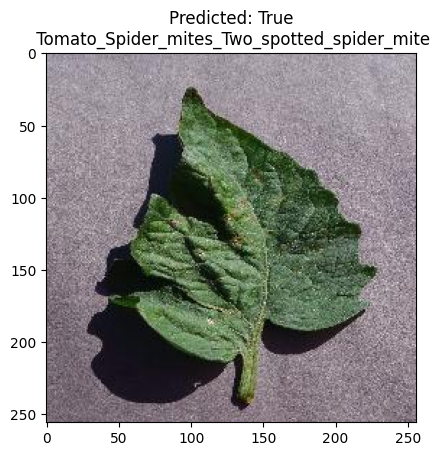

Predictions (probabilities for each class): [0.04664869 0.05248689 0.0083672  0.10312102 0.01557868 0.075984
 0.07237399 0.05983691 0.07044157 0.0905388  0.19536647 0.08772236
 0.09046151 0.01436738 0.01643373 0.00027075]
Predicted class index: 10


In [24]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Ensure your model is loaded (if it was saved earlier)
# model = tf.keras.models.load_model('path_to_your_model')  # Uncomment if loading a saved model

# Ensure correct dimensions for the model input
img_height = 180  # Match this to your model's input height
img_width = 180   # Match this to your model's input width

# Path to your custom image
image_path = r"C:\Users\harsh\OneDrive\Documents\project alok\PlantVillage\Tomato__Target_Spot\0a458dfc-b513-44f2-a3ce-dab4c3adb939___Com.G_TgS_FL 8166.JPG"
custom_image = tf.keras.utils.load_img(image_path, target_size=(img_height, img_width))
custom_image_array = tf.keras.utils.img_to_array(custom_image)  # Convert to array
custom_image_array = custom_image_array / 255.0  # Normalize pixel values to [0, 1]

# Add an extra batch dimension (model expects batch of images, even for a single image)
custom_image_array = np.expand_dims(custom_image_array, axis=0)

# Make a prediction
predictions = model.predict(custom_image_array)

# Get the class index with the highest probability
predicted_class = np.argmax(predictions[0])

# Get class names from the class_indices attribute
class_names = list(train_ds.class_indices.keys())  # Retrieve class names from class_indices
predicted_class_name = class_names[predicted_class]

# Display the image with the predicted class
plt.imshow(plt.imread(image_path))

plt.title(f"Predicted: True\n {predicted_class_name}")

plt.axis("on")
plt.show()

# Debugging: Show the raw prediction values (confidence for each class)
print("Predictions (probabilities for each class):", predictions[0])

print("Predicted class index:", predicted_class)


In [16]:
for layer in model.layers:
    print(layer.name)


rescaling_1
conv2d_3
max_pooling2d_3
conv2d_4
max_pooling2d_4
conv2d_5
max_pooling2d_5
global_average_pooling2d
dense_2
dense_3
